In [2]:
# training_ai.ipynb (PHIÊN BẢN CẢI THIỆN HIỆU SUẤT)

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
import warnings
import pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# =============================================================================
# SECTION 1: ĐỌC VÀ CHUẨN HÓA DỮ LIỆU GỐC
# =============================================================================
print("--- Bắt đầu quá trình huấn luyện nâng cao ---")
print("1. Đang đọc và chuẩn hóa dữ liệu...")

df = pd.read_csv('vietnam_housing_dataset.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Hàm chuẩn hóa
def standardize_legal_status(series):
    s_lower = series.str.lower().fillna('khác')
    cond_so_hong = s_lower.str.contains('have certificate', na=False)
    cond_hop_dong = s_lower.str.contains('sale contract', na=False)
    cond_cho_so = s_lower.str.contains('chờ sổ', na=False)
    return np.select([cond_so_hong, cond_hop_dong, cond_cho_so], ['Sổ hồng/Sổ đỏ', 'Hợp đồng', 'Đang chờ sổ'], default='Khác')

def standardize_furniture_state(series):
    s_lower = series.str.lower().fillna('khác')
    cond_day_du = s_lower.str.contains('full', na=False)
    cond_co_ban = s_lower.str.contains('basic', na=False)
    cond_khong_noi_that = s_lower.str.contains('none|không nội thất', na=False)
    return np.select([cond_day_du, cond_co_ban, cond_khong_noi_that], ['Nội thất đầy đủ', 'Nội thất cơ bản', 'Không nội thất'], default='Khác')

if 'legal_status' in df.columns: df['legal_status'] = standardize_legal_status(df['legal_status'])
if 'furniture_state' in df.columns: df['furniture_state'] = standardize_furniture_state(df['furniture_state'])

# Xử lý outliers (giữ nguyên)
numerical_cols_base = ['price', 'area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']
for col in numerical_cols_base:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['price', 'area']); df = df[(df['price'] > 0) & (df['area'] > 0)]
df['price_per_m2'] = df['price'] / df['area']
lower_bound, upper_bound = df['price_per_m2'].quantile([0.01, 0.99]) # Siết chặt hơn một chút
df = df[(df['price_per_m2'] >= lower_bound) & (df['price_per_m2'] <= upper_bound)]
df = df.drop(columns=['price_per_m2'])
print(f"    => Shape sau khi lọc outliers: {df.shape}")

# =============================================================================
# SECTION 2: HÀM TRÍCH XUẤT ĐỊA CHỈ ĐA CẤP (V5)
# =============================================================================
print("\n2. Đang trích xuất địa chỉ đa cấp (City/District/Sub-district)...")

def extract_location_v5(address):
    if pd.isna(address) or not isinstance(address, str) or not address.strip():
        return 'Other', 'Other', 'Other'
    addr = address.lower().replace('.', '')
    parts = [p.strip() for p in addr.split(',')]
    
    city_map = {'hà nội': 'HN', 'hồ chí minh': 'HCM', 'tp hcm': 'HCM', 'tphcm': 'HCM', 'sài gòn': 'HCM', 'hải phòng': 'HP', 'đà nẵng': 'ĐN', 'cần thơ': 'CT', 'bình dương': 'BD', 'đồng nai': 'Đồng Nai', 
                'bà rịa vũng tàu': 'BRVT', 'khánh hòa': 'KH', 'long an': 'LA', 'hưng yên': 'HY', 'an giang': 'An Giang', 'bắc giang': 'Bắc Giang', 'bắc kạn': 'Bắc Kạn', 'bạc liêu': 'Bạc Liêu', 
                'bắc ninh': 'Bắc Ninh', 'bến tre': 'Bến Tre', 'bình định': 'Bình Định', 'bình phước': 'Bình Phước', 'bình thuận': 'Bình Thuận', 'cà mau': 'Cà Mau', 'cao bằng': 'Cao Bằng', 
                'đắk lắk': 'Đắk Lắk', 'đắk nông': 'Đắk Nông', 'điện biên': 'Điện Biên', 'gia lai': 'Gia Lai', 'hà giang': 'Hà Giang', 'hà nam': 'Hà Nam', 'hà tĩnh': 'Hà Tĩnh', 
                'hải dương': 'Hải Dương', 'hậu giang': 'Hậu Giang', 'hòa bình': 'Hòa Bình', 'kiên giang': 'Kiên Giang', 'kon tum': 'Kon Tum', 'lai châu': 'Lai Châu', 'lâm đồng': 'Lâm Đồng', 
                'lạng sơn': 'Lạng Sơn', 'lào cai': 'Lào Cai', 'nam định': 'Nam Định', 'nghệ an': 'Nghệ An', 'ninh bình': 'Ninh Bình', 'ninh thuận': 'Ninh Thuận', 'phú thọ': 'Phú Thọ', 
                'phú yên': 'Phú Yên', 'quảng bình': 'Quảng Bình', 'quảng nam': 'Quảng Nam', 'quảng ngãi': 'Quảng Ngãi', 'quảng ninh': 'Quảng Ninh', 'quảng trị': 'Quảng Trị', 
                'sóc trăng': 'Sóc Trăng', 'sơn la': 'Sơn La', 'tây ninh': 'Tây Ninh', 'thái bình': 'Thái Bình', 'thái nguyên': 'Thái Nguyên', 'thanh hóa': 'Thanh Hóa', 'thừa thiên huế': 'Thừa Thiên Huế', 
                'huế': 'Thừa Thiên Huế', 'tiền giang': 'Tiền Giang', 'trà vinh': 'Trà Vinh', 'tuyên quang': 'Tuyên Quang', 'vĩnh long': 'Vĩnh Long', 'vĩnh phúc': 'Vĩnh Phúc', 'yên bái': 'Yên Bái'}
    
    found_city, found_district, found_sub_district = 'Other', 'Other', 'Other'
    
    district_keywords = ['quận', 'huyện', 'thị xã', 'thành phố', 'tp']
    sub_district_keywords = ['phường', 'xã', 'thị trấn']

    # Duyệt ngược để tìm các cấp hành chính
    for part in reversed(parts):
        # Tìm Phường/Xã
        if any(kw in part for kw in sub_district_keywords) and found_sub_district == 'Other':
            for kw in sub_district_keywords: part = part.replace(kw, '').strip()
            found_sub_district = part.title()
        # Tìm Quận/Huyện
        elif any(kw in part for kw in district_keywords) and found_district == 'Other':
             if not any(city_name in part for city_name in ['hà nội', 'hồ chí minh', 'hải phòng', 'đà nẵng', 'cần thơ']):
                for kw in district_keywords: part = part.replace(kw, '').strip()
                found_district = part.title()
        # Tìm Tỉnh/Thành phố
        if found_city == 'Other':
            for name, code in city_map.items():
                if name in part:
                    found_city = code
                    break
                    
    return found_city, found_district, found_sub_district

address_col_name = 'address'
df['city'], df['district'], df['sub_district'] = zip(*df[address_col_name].apply(extract_location_v5))
df = df.drop(address_col_name, axis=1, errors='ignore')
df['log_price'] = np.log1p(df['price'])
df['log_area'] = np.log1p(df['area'])

# =============================================================================
# SECTION 3: FEATURE ENGINEERING NÂNG CAO
# =============================================================================
print("\n3. Đang tạo các features nâng cao...")

train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

# --- Tạo các feature mới chỉ từ tập train để tránh data leakage ---
numerical_cols = ['log_area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']
district_medians = {col: train_df.groupby('district')[col].median().to_dict() for col in numerical_cols}
overall_medians = {col: train_df[col].median() for col in numerical_cols}

# Tạo hệ số giá của quận dựa trên log_price (Target Encoding)
district_log_price_avg = train_df.groupby('district')['log_price'].mean().to_dict()
global_log_price_avg = train_df['log_price'].mean()

good_dirs = ['Nam', 'Đông - Nam', 'Đông', 'Đông Nam']
cat_cols = ['house_direction', 'legal_status', 'furniture_state', 'city', 'district', 'sub_district']

def create_features_v2(d):
    df_copy = d.copy()
    # Impute và fillna
    for col in numerical_cols:
        if col in df_copy.columns: df_copy[col] = df_copy.apply(lambda row: district_medians[col].get(row['district'], overall_medians[col]) if pd.isna(row[col]) else row[col], axis=1)
    for col in cat_cols:
        if col in df_copy.columns: df_copy[col] = df_copy[col].fillna('Khác').astype(str)
    
    # --- Feature Engineering Nâng Cao ---
    # Đặc trưng đa thức
    # ── Feature Engineering Nâng Cao (dùng log_area thay vì area) ──
    df_copy['log_area_squared'] = df_copy['log_area'] ** 2                     # thay area_squared
    df_copy['district_price_modifier'] = df_copy['district'].map(district_log_price_avg).fillna(global_log_price_avg)
    df_copy['log_area_x_price_modifier'] = df_copy['log_area'] * df_copy['district_price_modifier']   # thay area_x_...
    
    df_copy['total_rooms'] = df_copy.get('bedrooms', 0).fillna(0) + df_copy.get('bathrooms', 0).fillna(0) + 1
    df_copy['rooms_per_log_area'] = df_copy['total_rooms'] / (df_copy['log_area'] + 1e-6)           # thay rooms_per_area
    
    # Đặc trưng cũ
    df_copy['is_good_direction'] = df_copy.get('house_direction', '').isin(good_dirs).astype(int)
    
    return df_copy

train_df = create_features_v2(train_df)
test_df = create_features_v2(test_df)

# =============================================================================
# SECTION 4: HUẤN LUYỆN MODEL VỚI BỘ THAM SỐ TỐT HƠN
# =============================================================================
print("\n4. Bắt đầu huấn luyện model với bộ tham số cải tiến...")

features = [
    # Cơ bản
    'log_area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms',
    # Vị trí đa cấp
    'city', 'district', 'sub_district',
    # Categorical
    'house_direction', 'legal_status', 'furniture_state',
    # Features mới
    'log_area_squared', 'district_price_modifier', 'log_    area_x_price_modifier',
    'total_rooms', 'rooms_per_log_area', 'is_good_direction'
]
features = [f for f in features if f in train_df.columns]
cat_cols = [c for c in cat_cols if c in features]

X_train = train_df[features]
y_train = train_df['log_price']
X_test = test_df[features]
y_test = test_df['log_price']

# Bộ tham số đã được tinh chỉnh (cho kết quả tốt hơn và chạy nhanh hơn)
tuned_params = {
    'iterations': 5000,
    'learning_rate': 0.01,
    'depth': 6,
    'l2_leaf_reg': 20,
    'loss_function': 'RMSE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'verbose': 500,
    'early_stopping_rounds': 200,
    'use_best_model': True,
    'subsample': 0.8,
}
model = CatBoostRegressor(**tuned_params)
model.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_test, y_test))

# =============================================================================
# SECTION 5: ĐÁNH GIÁ VÀ LƯU TRỮ
# =============================================================================
print("\n5. Đang đánh giá model và lưu trữ artifacts...")

y_pred_log = model.predict(X_test)
y_test_real, y_pred_real = np.expm1(y_test), np.expm1(y_pred_log)

print("\n=== Đánh giá trên tập Test (Mô hình nâng cao) ===")
print(f"    R² (Giá thật): {r2_score(y_test_real, y_pred_real):.4f}")
print(f"    MAE (Giá thật): {mean_absolute_error(y_test_real, y_pred_real):,.3f} tỷ VND")



--- Bắt đầu quá trình huấn luyện nâng cao ---
1. Đang đọc và chuẩn hóa dữ liệu...
    => Shape sau khi lọc outliers: (29624, 12)

2. Đang trích xuất địa chỉ đa cấp (City/District/Sub-district)...

3. Đang tạo các features nâng cao...

4. Bắt đầu huấn luyện model với bộ tham số cải tiến...
0:	learn: 0.2843628	test: 0.2876459	best: 0.2876459 (0)	total: 167ms	remaining: 13m 54s
500:	learn: 0.1717862	test: 0.1711149	best: 0.1711149 (500)	total: 10.7s	remaining: 1m 35s
1000:	learn: 0.1630534	test: 0.1637695	best: 0.1637695 (1000)	total: 31.1s	remaining: 2m 4s
1500:	learn: 0.1583368	test: 0.1602768	best: 0.1602768 (1500)	total: 47.3s	remaining: 1m 50s
2000:	learn: 0.1557544	test: 0.1583666	best: 0.1583666 (2000)	total: 59.1s	remaining: 1m 28s
2500:	learn: 0.1535193	test: 0.1568033	best: 0.1568033 (2500)	total: 1m 9s	remaining: 1m 9s
3000:	learn: 0.1518562	test: 0.1555683	best: 0.1555683 (2998)	total: 1m 18s	remaining: 52.5s
3500:	learn: 0.1503397	test: 0.1544853	best: 0.1544853 (3500)	total:

In [3]:
MODEL_PATH = r'E:\BDS_Baove\RealEstate_HUCE\backend\AI_Model\catboost_model.cbm'
PICKLE_PATH = r'E:\BDS_Baove\RealEstate_HUCE\backend\AI_Model\preprocess_globals.pkl'
model.save_model(MODEL_PATH)

# Cập nhật globals_dict để lưu các đối tượng mới
globals_dict = {
    'district_medians': district_medians, 'overall_medians': overall_medians,
    'district_log_price_avg': district_log_price_avg, 'global_log_price_avg': global_log_price_avg,
    'features': features, 'good_dirs': good_dirs,
    'numerical_cols': numerical_cols, 'cat_cols': cat_cols
}
with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(globals_dict, f)
print(f"\n    => Model và các biến tiền xử lý mới đã được lưu.")
print("\n--- Quá trình huấn luyện nâng cao đã hoàn tất! ---")


    => Model và các biến tiền xử lý mới đã được lưu.

--- Quá trình huấn luyện nâng cao đã hoàn tất! ---


In [4]:
%pip install catboost numpy pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


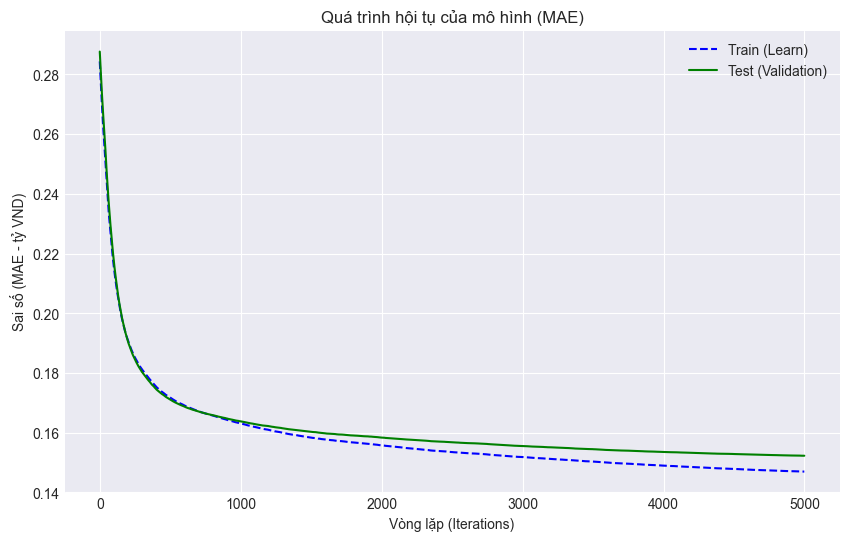

In [5]:
# Lấy kết quả huấn luyện
evals_result = model.get_evals_result()
iterations = range(len(evals_result['learn']['MAE']))

plt.figure(figsize=(10, 6))
plt.plot(iterations, evals_result['learn']['MAE'], label='Train (Learn)', color='blue', linestyle='--')
plt.plot(iterations, evals_result['validation']['MAE'], label='Test (Validation)', color='green')

plt.title('Quá trình hội tụ của mô hình (MAE)')
plt.xlabel('Vòng lặp (Iterations)')
plt.ylabel('Sai số (MAE - tỷ VND)')
plt.legend()
plt.show()